In [ ]:
#Step 1 : Random Forest Classifier (RFC) using 20 Newsgroup Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#Step 2
categories = None
newsgroups = fetch_20newsgroups(subset='all', categories=categories, shuffle = True, random_state = 42)

In [ ]:
#Step 3
print("Total documents : ", len(newsgroups.data))
print("Target names : ", newsgroups.target_names)

Total documents :  18846
Target names :  ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [ ]:
#Step 4
V = TfidfVectorizer(stop_words='english', max_df=0.5, min_df=2)
X = V.fit_transform(newsgroups.data)
y = newsgroups.target

In [ ]:
#Step 5
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Step 6
rfc = RandomForestClassifier(n_estimators =100, random_state = 42)

#Step 7
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#Step 8
y_pred = rfc.predict(X_test)

In [ ]:
# Step 9: Evaluate model performance
# Calculate and print the accuracy score
from sklearn.metrics import accuracy_score
accuracy = accuracy_score (y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%") # Multiply by 100 for percentage

Accuracy: 86.21%


In [ ]:
# Step 10: Print the classification report for detailed metrics
R = classification_report(y_test, y_pred, target_names=newsgroups.target_names)
print ("Classification Report: \n", R)

Classification Report: 
                           precision    recall  f1-score   support

             alt.atheism       0.90      0.84      0.87       151
           comp.graphics       0.72      0.82      0.77       202
 comp.os.ms-windows.misc       0.74      0.88      0.80       195
comp.sys.ibm.pc.hardware       0.67      0.69      0.68       183
   comp.sys.mac.hardware       0.89      0.84      0.87       205
          comp.windows.x       0.91      0.80      0.85       215
            misc.forsale       0.80      0.81      0.81       193
               rec.autos       0.88      0.88      0.88       196
         rec.motorcycles       0.94      0.93      0.93       168
      rec.sport.baseball       0.92      0.93      0.93       211
        rec.sport.hockey       0.90      0.98      0.94       198
               sci.crypt       0.95      0.95      0.95       201
         sci.electronics       0.88      0.71      0.79       202
                 sci.med       0.88      0.89     

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5]),
 [Text(0, 0.5, 'alt.atheism'),
  Text(0, 1.5, 'comp.graphics'),
  Text(0, 2.5, 'comp.os.ms-windows.misc'),
  Text(0, 3.5, 'comp.sys.ibm.pc.hardware'),
  Text(0, 4.5, 'comp.sys.mac.hardware'),
  Text(0, 5.5, 'comp.windows.x'),
  Text(0, 6.5, 'misc.forsale'),
  Text(0, 7.5, 'rec.autos'),
  Text(0, 8.5, 'rec.motorcycles'),
  Text(0, 9.5, 'rec.sport.baseball'),
  Text(0, 10.5, 'rec.sport.hockey'),
  Text(0, 11.5, 'sci.crypt'),
  Text(0, 12.5, 'sci.electronics'),
  Text(0, 13.5, 'sci.med'),
  Text(0, 14.5, 'sci.space'),
  Text(0, 15.5, 'soc.religion.christian'),
  Text(0, 16.5, 'talk.politics.guns'),
  Text(0, 17.5, 'talk.politics.mideast'),
  Text(0, 18.5, 'talk.politics.misc'),
  Text(0, 19.5, 'talk.religion.misc')])

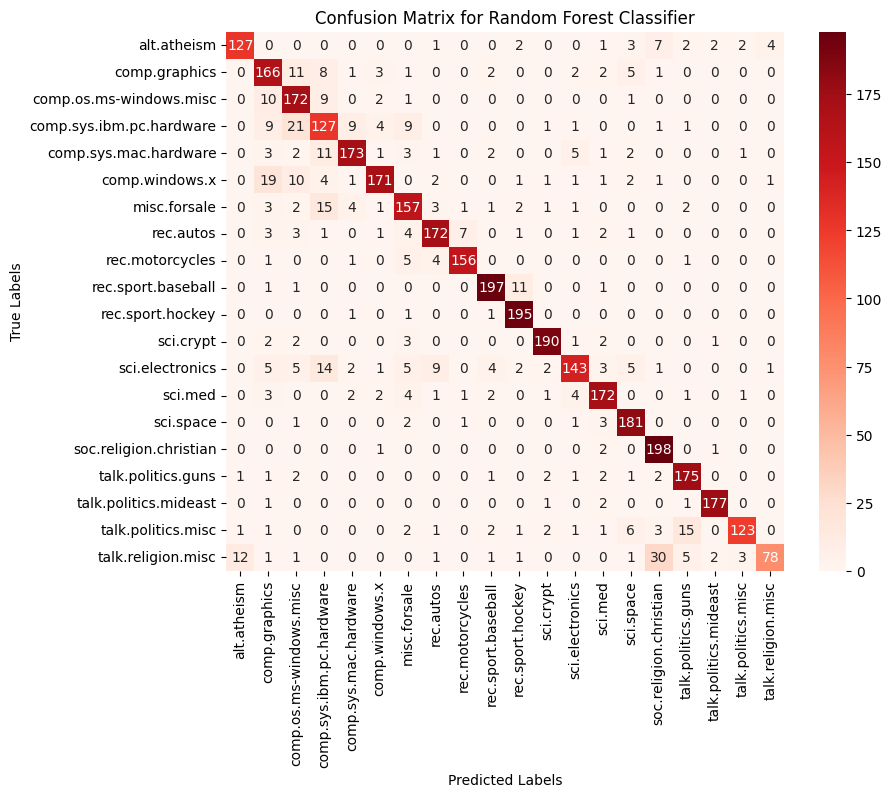

In [ ]:
# Step 11: Plot a confusion matrix for the test set predictions
# This will show the classification performance for each class
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, cmap='Reds', fmt='d', xticklabels=newsgroups.target_names, yticklabels=newsgroups.target_names)
plt.title("Confusion Matrix for Random Forest Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

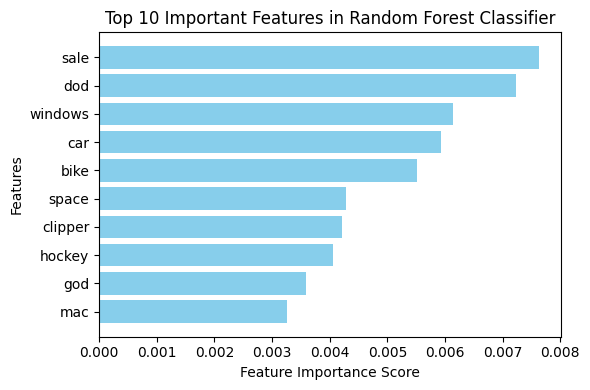

In [ ]:
# Step 12: Plot feature importance
# Random Forest allows us to inspect feature importance, which can help understand model focus areas
imp = rfc.feature_importances_
inx = np.argsort(imp)[-10:] # Top 10 important features
top_features = [V.get_feature_names_out()[i] for i in inx]
plt.figure(figsize=(6, 4))
plt.barh(range(len(top_features)), imp[inx], color='skyblue')
plt.yticks(range(len(top_features)), top_features)
plt.title("Top 10 Important Features in Random Forest Classifier")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

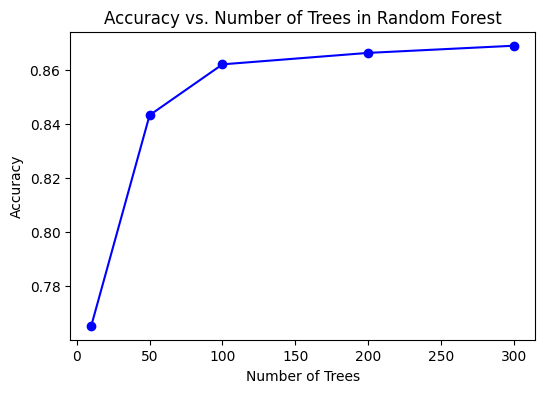

In [ ]:
# Step 13: Plot the accuracy trend by number of trees in Random Forest
# This helps determine if adding more trees would improve the model's performance
tree_counts = [10, 50, 100, 200, 300]
accuracies = []

for n_trees in tree_counts:
    rf_temp = RandomForestClassifier(n_estimators = n_trees, random_state=42)
    rf_temp.fit(X_train, y_train)
    y_pred_temp = rf_temp.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_temp))

plt.figure(figsize=(6, 4))
plt.plot(tree_counts, accuracies, marker='o', color='b')
plt.title("Accuracy vs. Number of Trees in Random Forest")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.show()